# 1. Embeddings


Some imports, gpu definitions

In [3]:
import json
import re
import torch
import stanza
from transformers import AutoTokenizer
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset


/Users/erannovak/miniconda3/envs/openUNLP/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Check if MPS is supported and available- I'm using mac
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Success: Using Apple M2 GPU Acceleration")
else:
    device = torch.device("cpu")
    print("Using CPU (Slow)")

Success: Using Apple M2 GPU Acceleration


## 1.1 Loading the input text
Loading text, and some regex cleaning

In [4]:
with open("data/801word_problems.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
    print("Data loaded successfully")

print("Total number of character:", len(raw_text))

Data loaded successfully
Total number of character: 245615


In [5]:
clean_text = re.sub(r"[#]", "", raw_text)
tokenizer = AutoTokenizer.from_pretrained("onlplab/alephbert-base")
text = tokenizer.tokenize(clean_text)
print("Tokenization complete using AlephBERT tokenizer.")
with open("output/text_alphabert.json", "w", encoding="utf-8") as f:
    json.dump(text, f)
    print("Text data saved to 'output/text_alphabert.json'")


Token indices sequence length is longer than the specified maximum sequence length for this model (68582 > 512). Running this sequence through the model will result in indexing errors


Tokenization complete using AlephBERT tokenizer.
Text data saved to 'output/text_alphabert.json'


## 1.2 Hebrew tokenization with 'stanza'
Using stanza library for tokenization. This tokenization takes a while, so I saved the output in a json file.

In [6]:
stanza.download("he")
try:
    nlp = stanza.Pipeline(
        lang="he", processors="tokenize,mwt", device=device  # <--- כאן השינוי החשוב
    )
    print(f"Success! Running on: {nlp.device}")

except Exception as e:
    print(f"Failed to load on {device}, falling back to CPU. Error: {e}")
    nlp = stanza.Pipeline(lang="he", processors="tokenize,mwt", device="cpu")
doc = nlp(clean_text)
text = [word.text for sent in doc.sentences for word in sent.words]
print("Tokenization complete using Stanza tokenizer.")
with open("output/text_stanza.json", "w", encoding="utf-8") as f:
    json.dump(text, f)
    print("Text data saved to 'output/text_stanza.json'")

2026-02-11 10:51:02 INFO: Downloaded file to /Users/erannovak/stanza_resources/resources.json
2026-02-11 10:51:02 INFO: Downloading default packages for language: he (Hebrew) ...
2026-02-11 10:51:03 INFO: File exists: /Users/erannovak/stanza_resources/he/default.zip
2026-02-11 10:51:05 INFO: Finished downloading models and saved to /Users/erannovak/stanza_resources
2026-02-11 10:51:05 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-02-11 10:51:05 INFO: Downloaded file to /Users/erannovak/stanza_resources/resources.json
2026-02-11 10:51:05 INFO: Loading these models for language: he (Hebrew):
| Processor | Package           |
---------------------------------
| tokenize  | combined_nocharlm |
| mwt       | combined          |

2026-02-11 10:51:05 INFO: Using device: mps
2026-02-11 10:51:05 INFO: Loading: tokenize
2026-02-11 10:51:06 INFO:

Success! Running on: mps
Tokenization complete using Stanza tokenizer.
Text data saved to 'output/text_stanza.json'


## 1.3 Prepare for training
creating vocabulary and dictionaries for word to index transform, and vice versa.

In [54]:
text = json.load(open("output/text_stanza.json", "r", encoding="utf-8"))
# print(text[:30])
vocab = sorted(set(text))
print(f"Vocabulary size: {len(vocab)}")
word2idx = {token: idx for idx, token in enumerate(vocab)}
idx2word = {idx: token for idx, token in enumerate(vocab)}

Vocabulary size: 4688


In [73]:
from collections import Counter
TOP_N = 100

# `text` is assumed to be the token list already defined in the notebook
counter = Counter(text)
most_common = counter.most_common(TOP_N)

print(f"Total tokens: {len(text)}")
print(f"Unique tokens (vocab): {len(counter)}")
# print(f"\nTop {TOP_N} most common tokens:\n")
# for i, (token, freq) in enumerate(most_common, 1):
#     print(f"{i:3d}. {token!r:20} {freq}")

Total tokens: 71815
Unique tokens (vocab): 4688


Generating skip gram - used window size of 8 because in word question the context is not very long or complicated.

In [24]:
def generate_skip_grams(text, window_size=4):
    skip_grams = []
    for i, word in enumerate(text):
        # Define the context window
        start = max(0, i - window_size)
        end = min(len(text), i + window_size + 1)
        context = [w for j, w in enumerate(text[start:end]) if j != window_size]
        for w in context:
            skip_grams.append((word, w))
    return skip_grams

In [25]:
WINDOW_SIZE = 8
skip_grams = generate_skip_grams(text, window_size=WINDOW_SIZE)
print(f"Total skip-grams generated: {len(skip_grams)}")
print("sample skip-grams:", skip_grams[:5])
# saving skip-grams to a file
with open("output/skip_grams.json", "w", encoding="utf-8") as f:
    json.dump(skip_grams, f)
    print("Skip-grams data saved to 'data/skip_grams.json'")

Total skip-grams generated: 1148968
sample skip-grams: [('\ufeffא.', '\ufeffא.'), ('\ufeffא.', 'נתונים'), ('\ufeffא.', 'שני'), ('\ufeffא.', 'מספרים'), ('\ufeffא.', '.')]
Skip-grams data saved to 'data/skip_grams.json'


Creating dataset (for the dataloader and training)

In [26]:
class Word2VecDataset(Dataset):
    def __init__(self, tokens, window_size=WINDOW_SIZE):
        self.data = []
        # Generate all positive pairs once
        for i, center_word in enumerate(tokens):
            start = max(0, i - window_size)
            end = min(len(tokens), i + window_size + 1)
            for j in range(start, end):
                if i != j:
                    self.data.append((word2idx[center_word], word2idx[tokens[j]]))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        center, context = self.data[idx]
        return torch.tensor(center), torch.tensor(context)

## 1.4 Model and training
creating the model with negative skipgram sampling

In [27]:
# model, with negative sampling
class SkipGramNegativeSampling(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramNegativeSampling, self).__init__()

        # We need two sets of embeddings:
        # 1. Target embeddings (center words)
        # 2. Context embeddings (words surrounding the center)
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)

        self.in_embed.weight.data.uniform_(-0.5, 0.5)
        self.out_embed.weight.data.uniform_(-0.5, 0.5)

    def forward(self, input_words, output_words):
        # input_words shape: [batch_size]
        # output_words shape: [batch_size] (positives) OR [batch_size * k] (negatives)

        in_vecs = self.in_embed(input_words)  # Shape: [batch_size, emb_dim]
        out_vecs = self.out_embed(output_words)  # Shape: [batch_size, emb_dim]

        # We want the dot pimplest batch implementation:

        # Element-wise multiplication then sum over embedding dimension
        scores = torch.sum(in_vecs * out_vecs, dim=1)

        return scores

training loop

In [32]:
VOCAB_SIZE = len(word2idx)
EMBEDDING_DIM = 200
BATCH_SIZE = 64
K_NEGATIVES = 16  # Number of negative samples per real pair
LR = 0.002  # found 0.002 as suitable learning rate
EPOCHS = 15

In [33]:
dataset = Word2VecDataset(text, window_size=WINDOW_SIZE)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model = SkipGramNegativeSampling(VOCAB_SIZE, EMBEDDING_DIM)
model.to(device)

SkipGramNegativeSampling(
  (in_embed): Embedding(4688, 200)
  (out_embed): Embedding(4688, 200)
)

In [34]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

In [35]:
print(f"Training on vocab size {VOCAB_SIZE} with {len(dataset)} pairs...")
loss_history = []
for epoch in range(EPOCHS):
    total_loss = 0

    for center_batch, context_batch in dataloader:
        center_batch = center_batch.to(device)
        context_batch = context_batch.to(device)
        # --- A. Positive Samples (Real pairs) ---
        # Label is 1 for real pairs
        pos_scores = model(center_batch, context_batch)
        pos_labels = torch.ones_like(pos_scores, device=device)
        pos_loss = criterion(pos_scores, pos_labels)

        # --- B. Negative Samples (Fake pairs) ---
        # Generate random words from vocab (noise)
        # Shape: [Batch_Size * K]
        neg_context = torch.randint(
            0, VOCAB_SIZE, (len(center_batch) * K_NEGATIVES,), device=device
        )

        # Repeat center words to match negative context count
        # [center1, center2] -> [center1, center1, center1..., center2, center2...]
        center_batch_expanded = center_batch.repeat_interleave(K_NEGATIVES)

        # Label is 0 for fake pairs
        neg_scores = model(center_batch_expanded, neg_context)
        neg_labels = torch.zeros_like(neg_scores, device=device)
        neg_loss = criterion(neg_scores, neg_labels)

        # --- C. Update ---
        loss = pos_loss + neg_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: Loss {total_loss/len(dataloader):.4f}")
    loss_history.append(total_loss / len(dataloader))

Training on vocab size 4688 with 1148968 pairs...
Epoch 1: Loss 0.7009
Epoch 2: Loss 0.4933
Epoch 3: Loss 0.4561
Epoch 4: Loss 0.4464
Epoch 5: Loss 0.4426
Epoch 6: Loss 0.4407
Epoch 7: Loss 0.4399
Epoch 8: Loss 0.4398
Epoch 9: Loss 0.4398
Epoch 10: Loss 0.4396
Epoch 11: Loss 0.4406
Epoch 12: Loss 0.4403
Epoch 13: Loss 0.4413
Epoch 14: Loss 0.4419
Epoch 15: Loss 0.4425


Saving the model (the embeddings)

In [36]:
torch.save(model.state_dict(), "output/embedding_model_stanza.pth")

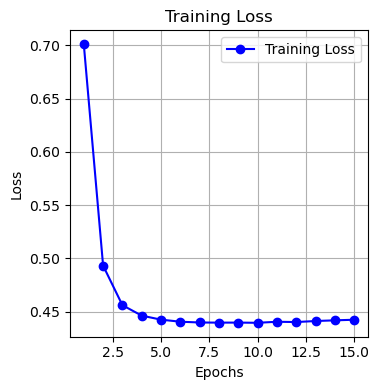

In [38]:
from matplotlib import pyplot as plt
def plot_training_history(train_loss):
    epochs_range = range(1, len(train_loss) + 1)

    plt.figure(figsize=(7, 4))

    # Plot 1: Loss vs. Epochs
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_loss, 'b-o', label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)


    plt.tight_layout()
    plt.show()

# Call the function with your history lists
plot_training_history(loss_history)

## 1.5 Test embeddings
Now that we trained the model, we can use its output embeddings layer to create embeddings to the words in our vocabulary. For now we can test cosine similarity between words, to check if our model is working. We can expect that embeddings similarity will be found between words of similar meanings. In the next code I used TSNE algorithm to lower embeddings dimentions so that it can be seen on a plot.

In [ ]:
import torch
import numpy as np

def get_word_embedding(
    word: str,
    model,
    word2idx: dict,
    embedding: str = "in",
    normalize: bool = True,
    device=None,
):
    """
    Return a single-word embedding vector from the trained SkipGram model.

    """

    if word not in word2idx:
        raise KeyError(f"Word not in vocabulary: {word}")

    idx = word2idx[word]

    if embedding.lower() in ("in", "input", "center"):
        emb_layer = model.in_embed
    elif embedding.lower() in ("out", "context"):
        emb_layer = model.out_embed
    else:
        raise ValueError("embedding must be 'in' or 'out'")

    # fetch weight vector for the index
    with torch.no_grad():
        vec = emb_layer.weight.data[idx].to("cpu").clone()

    if normalize:
        norm = vec.norm(p=2)
        if norm > 0:
            vec = vec / norm

    return vec.numpy()

In [44]:
sample = get_word_embedding("מכונית", model, word2idx, embedding="in", normalize=True, device=device)
print(sample.shape)

(200,)


conncatanate and normalize embeddings for all the words in VOCAB

In [45]:
embedding_layer = model.in_embed

# prepare embedding matrix (cpu numpy)
emb_matrix = embedding_layer.weight.detach().cpu().numpy()
# normalize for cosine similarity
norms = np.linalg.norm(emb_matrix, axis=1, keepdims=True)
norms[norms == 0] = 1.0
emb_norm = emb_matrix / norms

In [74]:
print(emb_matrix.shape)

(4688, 200)


find the top k neighbors, with the most cosine similarity

In [51]:
def top_k_neighbors(target_word, k=10):
    if target_word not in word2idx:
        raise KeyError(f"Word '{target_word}' not in vocabulary.")
    idx = word2idx[target_word]
    target_vec = emb_norm[idx : idx + 1]  # shape (1, dim)
    sims = emb_norm.dot(target_vec.T).squeeze()  # cosine similarities
    # exclude the word itself
    sims[idx] = -1.0
    topk_idx = sims.argsort()[::-1][:k]
    topk_idx_list = [int(i) for i in topk_idx]
    return [(idx2word[int(i)], float(sims[int(i)])) for i in topk_idx_list], topk_idx_list

Show results in 2-D plot using TSNE

In [56]:
from sklearn.manifold import TSNE # lower embedding dimentions
from bidi.algorithm import get_display # display Hebrew text correctly

def visualize_neighbors(target_word, k=20, perplexity=15, figsize=(8, 6)):
    neighbors, idxs = top_k_neighbors(target_word, k=k)
    target_idx = word2idx[target_word]
    indices = np.concatenate(([target_idx], idxs))
    subset_vecs = emb_matrix[indices]

    tsne = TSNE(
        n_components=2,
        perplexity=min(perplexity, max(5, len(indices) - 1)),
        random_state=0,
    )
    coords = tsne.fit_transform(subset_vecs)

    plt.figure(figsize=figsize)
    plt.scatter(
        coords[1:, 0], coords[1:, 1], c="C0", alpha=0.8, s=60, label="neighbors"
    )
    plt.scatter(coords[0, 0], coords[0, 1], c="C1", s=100, label=target_word)
    sims_for_plot = [1.0] + [sim for (_w, sim) in neighbors]

    # annotate: use bidi.get_display to render Hebrew right-to-left and align text to the right of the point
    for i, idx in enumerate(indices):
        w = idx2word[int(idx)]
        w_disp = get_display(w)  # reorder for RTL display
        sim = sims_for_plot[i]
        x, y = coords[i]
        label = f"{w_disp} ({sim:.2f})" if i != 0 else f"{w_disp} (1.00)"
        plt.text(
            x,
            y,
            label,
            fontsize=12 if i == 0 else 10,
            ha="right",  # align text to the right so it reads RTL from the point
            va="center",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1.0),
        )

    plt.title(f"Local neighborhood for '{target_word}' (top {k})-model #3")
    plt.legend()
    plt.tight_layout()
    plt.show()


Some tests - results are very impressive, concidering the relativly small datasets. We can see that embeddings similarity is (usually) found between word that are close in meaning. 

Top neighbors: ([('בלימה', 0.3924647271633148), ('נהג', 0.34638872742652893), ('איתן', 0.33548012375831604), ('בלימת', 0.33280709385871887), ('פתיחה', 0.3315642476081848), ('פרטית', 0.3310540020465851)], [1463, 3476, 1259, 1464, 4027, 4013])


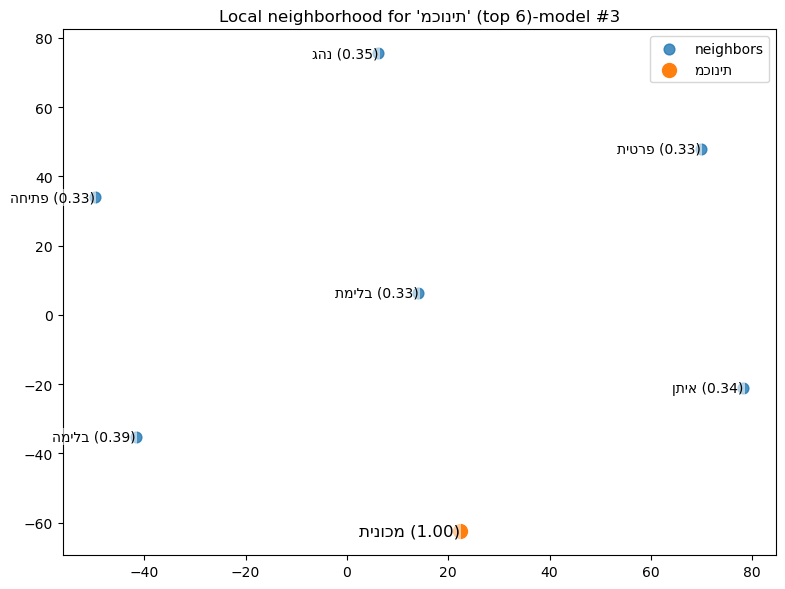

In [57]:
word = "מכונית"
print("Top neighbors:", top_k_neighbors(word, k=6))
visualize_neighbors(word, k=6)

Top neighbors: ([('זווית', 0.5631806254386902), ('שוקיים', 0.5155748128890991), ('ABC', 0.4645730257034302), ('ישר', 0.4521564841270447), ('משולשים', 0.442545086145401), ('ישרה', 0.4304300546646118)], [2023, 4365, 961, 2424, 3331, 2427])


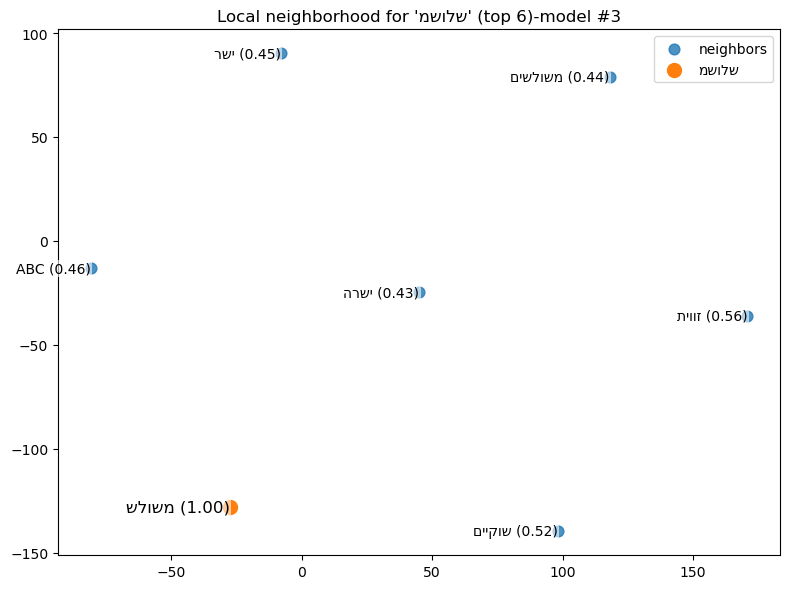

In [61]:
word = "משולש"
print("Top neighbors:", top_k_neighbors(word, k=6))
visualize_neighbors(word, k=6)

Top neighbors: ([('לבעוט', 0.7640472650527954), ('ניחש', 0.6913464665412903), ('קיבלתי', 0.6494832038879395), ('הבחין', 0.6305190324783325), ('שוער', 0.5890415906906128), ('סיכוי', 0.5820692181587219)], [2585, 3538, 4163, 1678, 4357, 3726])


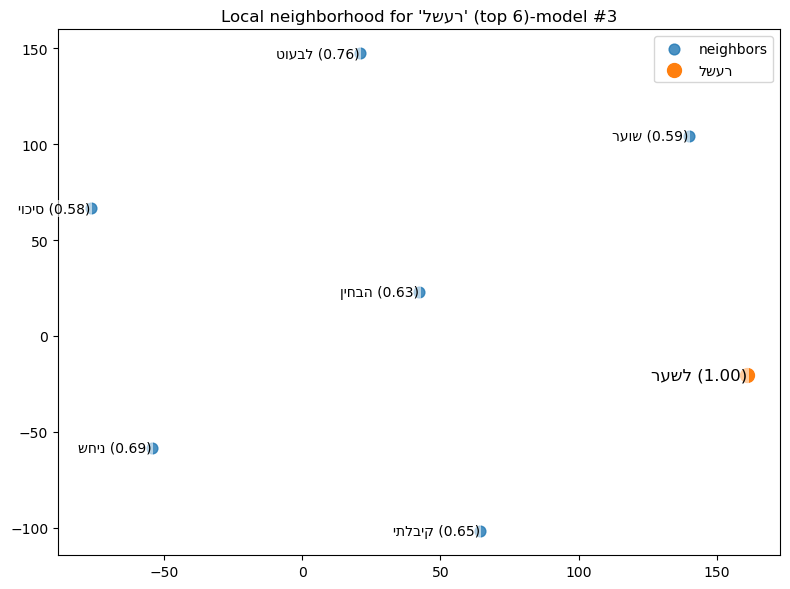

In [64]:
word = "לשער"
print("Top neighbors:", top_k_neighbors(word, k=6))
visualize_neighbors(word, k=6)

Top neighbors: ([('צלע', 0.4587544798851013), ('ס"מ', 0.4209584891796112), ('מלבן', 0.41948986053466797), ('משולש', 0.3648641109466553), ('הצלע', 0.3178005814552307), ('ריבוע', 0.31528064608573914)], [4083, 3680, 3115, 3330, 1899, 4267])


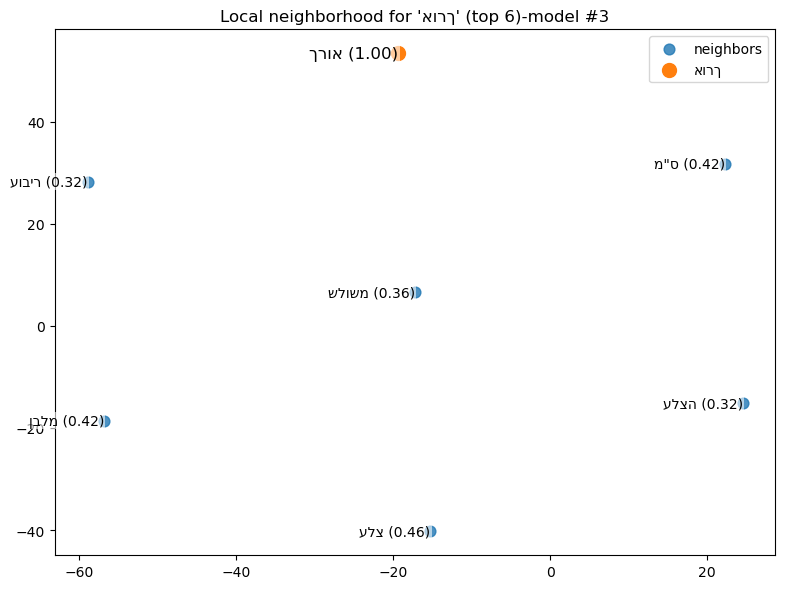

In [72]:
word = "אורך"
print("Top neighbors:", top_k_neighbors(word, k=6))
visualize_neighbors(word, k=6)